<a href="https://colab.research.google.com/github/MohamedAhmedGalal/AI_fake_audios/blob/main/AI_fake_voices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import requests
import librosa
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

# Load first sample (your mp3 file)
y1, sr1 = librosa.load('/content/sample.mp3', sr=None)
print(f"Sample 1: Duration {len(y1)/sr1:.2f}s, Sample rate: {sr1}Hz")


Sample 1: Duration 84.57s, Sample rate: 44100Hz


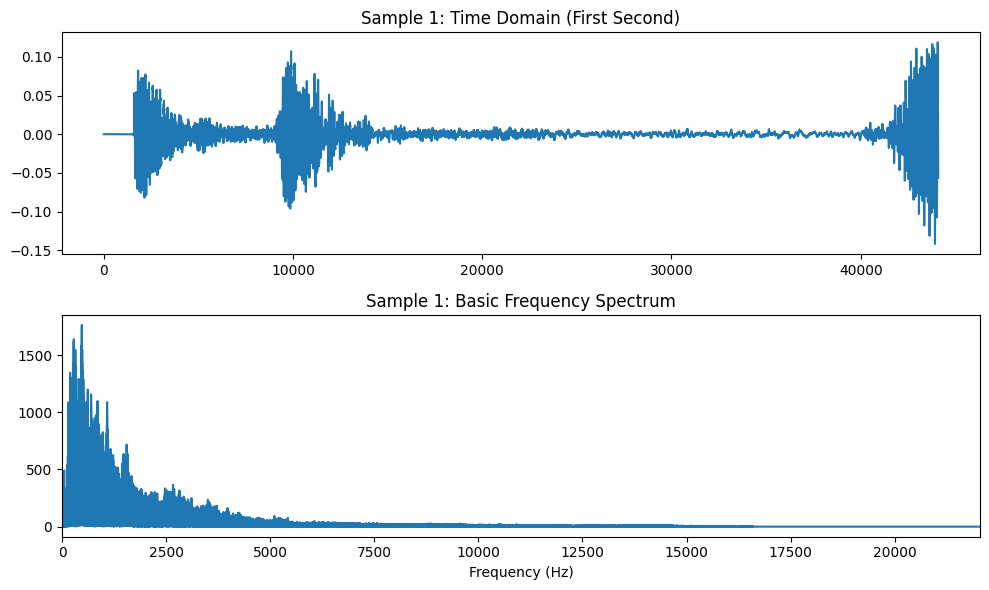

In [26]:
# FFT computation
# Basic FFT for sample 1
N1 = len(y1)
yf1 = fft(y1)
xf1 = fftfreq(N1, 1/sr1)[:N1//2]
magnitude1 = np.abs(yf1[:N1//2])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.plot(y1[:sr1])
ax1.set_title('Sample 1: Time Domain (First Second)')
ax2.plot(xf1, magnitude1)
ax2.set_title('Sample 1: Basic Frequency Spectrum')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_xlim(0, sr1/2)
plt.tight_layout()
plt.show()



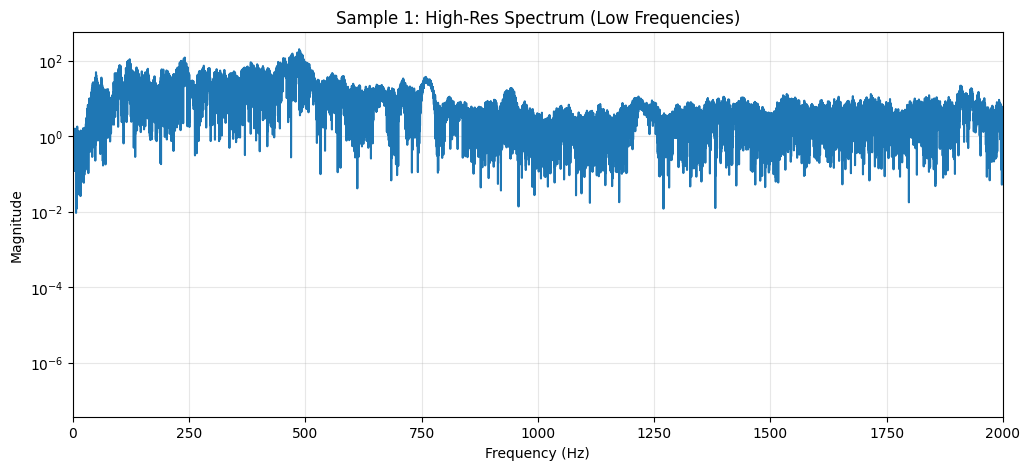

Sample 1 FFT resolution: 0.01 Hz/bin


In [27]:
# High-res FFT with zero-padding for sample 1
duration1 = 10
samples1 = int(duration1 * sr1)
y1_segment = y1[:samples1] if len(y1) > samples1 else np.pad(y1, (0, samples1 - len(y1)))
window1 = np.hanning(len(y1_segment))
y1_windowed = y1_segment * window1

N_fft1 = len(y1_windowed) * 8
yf1_hr = fft(y1_windowed, n=N_fft1)
xf1_hr = fftfreq(N_fft1, 1/sr1)[:N_fft1//2]
magnitude1_hr = np.abs(yf1_hr[:N_fft1//2])

plt.figure(figsize=(12, 5))
plt.semilogy(xf1_hr, magnitude1_hr)
plt.title('Sample 1: High-Res Spectrum (Low Frequencies)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 2000)
plt.grid(True, alpha=0.3)
plt.show()
print(f"Sample 1 FFT resolution: {sr1/N_fft1:.2f} Hz/bin")



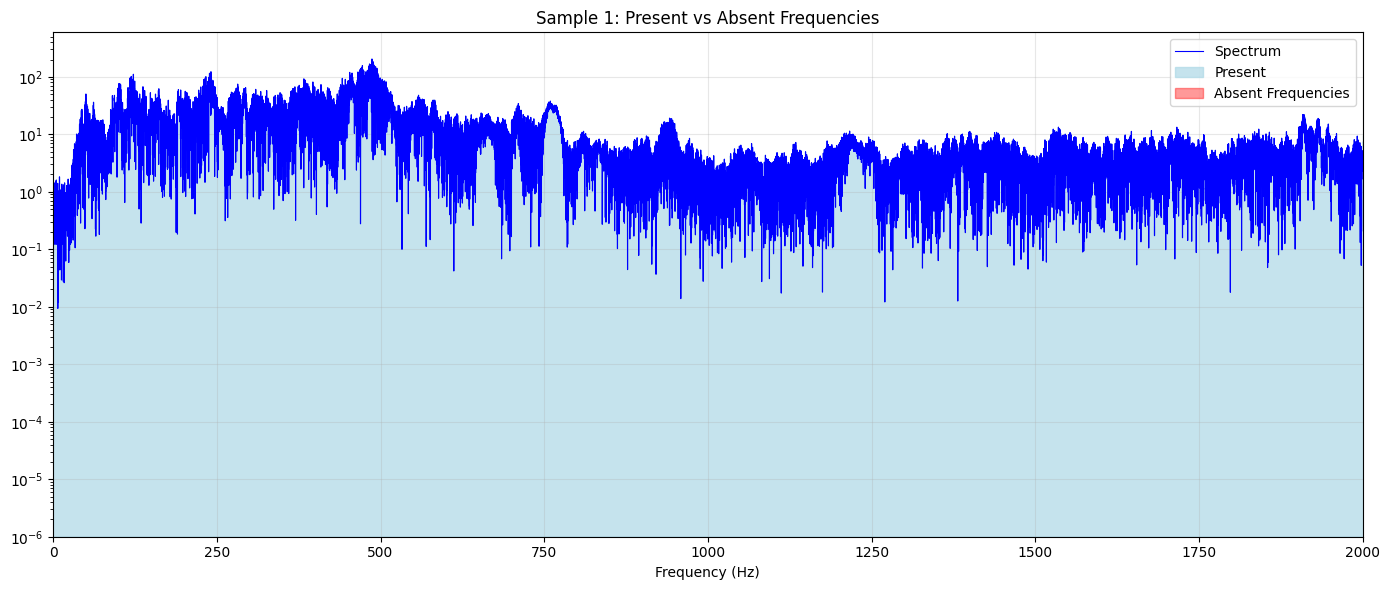

Sample 1 - Absent ranges: 7111.1-7111.2 Hz, 11569.8-11569.9 Hz, 11653.9-11654.0 Hz, 11895.1-11895.2 Hz, 12311.3-12311.4 Hz, 12330.5-12330.6 Hz, 12769.2-12769.3 Hz, 12804.7-12804.8 Hz, 13052.1-13052.2 Hz, 13091.3-13091.4 Hz, 13242.1-13242.2 Hz, 13243.6-13243.8 Hz, 14202.6-14202.8 Hz, 14333.2-14333.3 Hz, 14417.8-14417.9 Hz, 14493.9-14494.0 Hz, 14858.7-14858.8 Hz, 14866.5-14866.6 Hz, 14915.1-14915.3 Hz, 15022.7-15022.9 Hz, 15043.8-15043.9 Hz, 15061.0-15061.2 Hz, 15126.8-15127.0 Hz, 15225.1-15225.3 Hz, 15278.9-15279.0 Hz, 15386.3-15386.4 Hz, 15419.2-15419.3 Hz, 15435.8-15435.9 Hz, 15442.2-15442.3 Hz, 15445.0-15445.2 Hz, 15463.5-15463.6 Hz, 15523.2-15523.3 Hz, 15534.6-15534.7 Hz, 15553.4-15553.5 Hz, 15556.5-15556.7 Hz, 15672.1-15672.2 Hz, 15792.9-15793.1 Hz, 15794.3-15794.4 Hz, 15794.5-15794.6 Hz, 15804.7-15805.0 Hz, 15808.9-15809.0 Hz, 15819.7-15819.8 Hz, 15821.4-15821.6 Hz, 15860.4-15860.6 Hz, 15864.7-15864.8 Hz, 15868.7-15868.9 Hz, 15872.5-15872.9 Hz, 15874.3-15874.5 Hz, 15876.6-15876.8 

In [28]:
# Absent frequency detection for sample 1
magnitude1_db = 20 * np.log10(np.abs(yf1_hr[:N_fft1//2]) + 1e-12)
noise_floor1 = -60
is_absent1 = magnitude1_db < noise_floor1
gap_mask1 = np.convolve(is_absent1, np.ones(10), mode='same') > 0.5

fig, ax = plt.subplots(figsize=(14, 6))
ax.semilogy(xf1_hr, np.abs(yf1_hr[:N_fft1//2]), 'b-', linewidth=0.8, label='Spectrum')
ax.fill_between(xf1_hr, 1e-6, np.maximum(np.abs(yf1_hr[:N_fft1//2]), 1e-6),
                where=~gap_mask1, color='lightblue', alpha=0.7, label='Present')
ax.fill_between(xf1_hr, 1e-6, np.maximum(np.abs(yf1_hr[:N_fft1//2]), 1e-6),
                where=gap_mask1, color='red', alpha=0.4, label='Absent Frequencies')

ax.set_title('Sample 1: Present vs Absent Frequencies')
ax.set_xlabel('Frequency (Hz)')
ax.set_xlim(0, 2000)
ax.set_ylim(1e-6, None)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Print gaps
gaps1 = []
start = None
for i, absent in enumerate(gap_mask1):
    if absent and start is None:
        start = xf1_hr[i]
    elif not absent and start is not None:
        gaps1.append(f"{start:.1f}-{xf1_hr[i]:.1f} Hz")
        start = None
if start is not None:
    gaps1.append(f"{start:.1f}-{xf1_hr[-1]:.1f} Hz")
print("Sample 1 - Absent ranges:", ", ".join(gaps1))


In [30]:
import requests
import librosa
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

# Load second sample (your second mp3 file)
y2, sr2 = librosa.load('/content/sample_2.mp3', sr=None)  # Change filename if needed
print(f"Sample 2: Duration {len(y2)/sr2:.2f}s, Sample rate: {sr2}Hz")


Sample 2: Duration 60.46s, Sample rate: 44100Hz


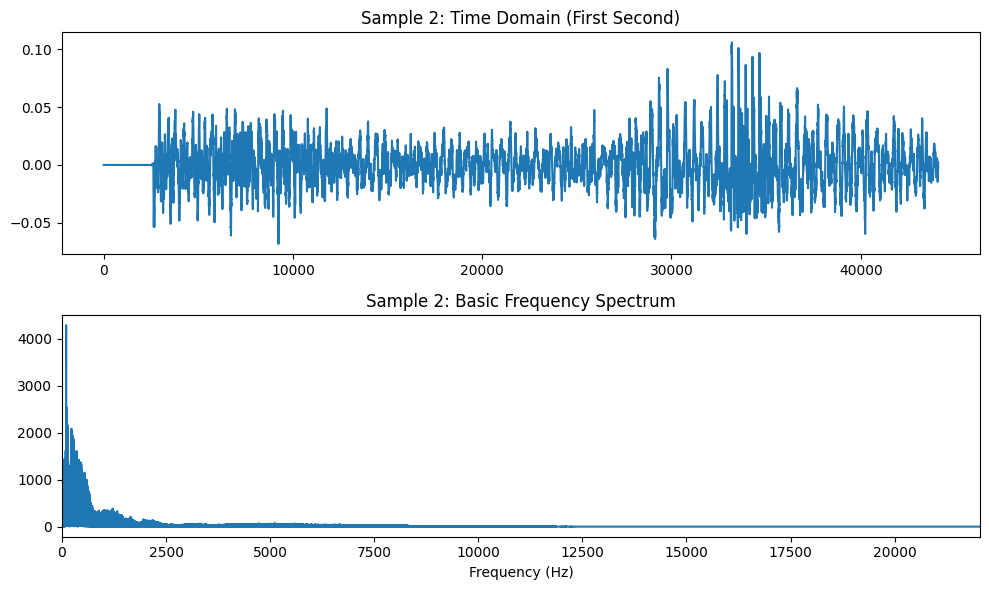

In [31]:
# Basic FFT for sample 2
N2 = len(y2)
yf2 = fft(y2)
xf2 = fftfreq(N2, 1/sr2)[:N2//2]
magnitude2 = np.abs(yf2[:N2//2])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.plot(y2[:sr2])
ax1.set_title('Sample 2: Time Domain (First Second)')
ax2.plot(xf2, magnitude2)
ax2.set_title('Sample 2: Basic Frequency Spectrum')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_xlim(0, sr2/2)
plt.tight_layout()
plt.show()


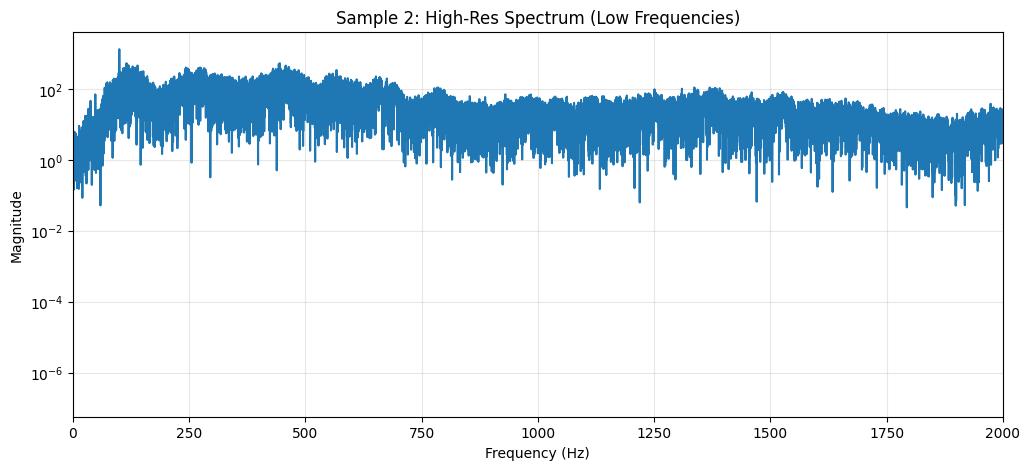

Sample 2 FFT resolution: 0.01 Hz/bin


In [33]:
# High-res FFT with zero-padding for sample 2
duration2 = 10
samples2 = int(duration2 * sr2)
y2_segment = y2[:samples2] if len(y2) > samples2 else np.pad(y2, (0, samples2 - len(y2)))
window2 = np.hanning(len(y2_segment))
y2_windowed = y2_segment * window2

N_fft2 = len(y2_windowed) * 8
yf2_hr = fft(y2_windowed, n=N_fft2)
xf2_hr = fftfreq(N_fft2, 1/sr2)[:N_fft2//2]
magnitude2_hr = np.abs(yf2_hr[:N_fft2//2])

plt.figure(figsize=(12, 5))
plt.semilogy(xf2_hr, magnitude2_hr)
plt.title('Sample 2: High-Res Spectrum (Low Frequencies)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 2000)
plt.grid(True, alpha=0.3)
plt.show()
print(f"Sample 2 FFT resolution: {sr2/N_fft2:.2f} Hz/bin")




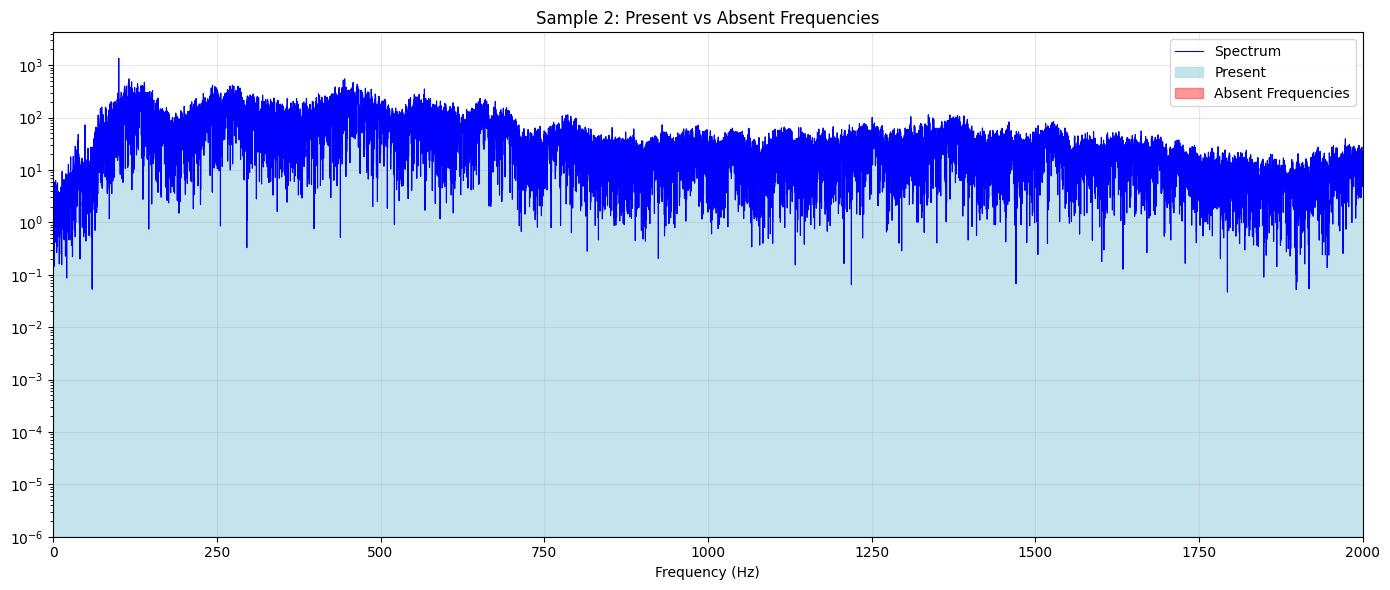

Sample 2 - Absent ranges: 8116.3-8116.4 Hz, 11600.4-11600.5 Hz, 12054.3-12054.4 Hz, 12056.3-12056.4 Hz, 12060.8-12061.1 Hz, 12334.4-12334.6 Hz, 12335.2-12335.4 Hz, 12338.9-12339.0 Hz, 12350.4-12350.6 Hz, 12352.0-12352.1 Hz, 12352.5-12352.7 Hz, 12356.6-12356.7 Hz, 12357.1-12357.2 Hz, 12359.3-12359.4 Hz, 12359.8-12360.0 Hz, 12361.3-12361.4 Hz, 12362.9-12363.1 Hz, 12363.9-12364.1 Hz, 12364.4-12364.6 Hz, 12364.9-12365.1 Hz, 12365.5-12365.6 Hz, 12366.0-12366.2 Hz, 12366.5-12366.7 Hz, 12367.0-12367.2 Hz, 12368.1-12368.2 Hz, 12368.6-12368.7 Hz, 12369.1-12369.2 Hz, 12369.7-12369.8 Hz, 12370.1-12370.3 Hz, 12370.6-12370.8 Hz, 12371.2-12371.3 Hz, 12371.7-12371.9 Hz, 12372.2-12372.4 Hz, 12374.2-12374.4 Hz, 12374.8-12374.9 Hz, 12375.3-12375.5 Hz, 12376.4-12376.6 Hz, 12377.9-12378.0 Hz, 12379.0-12379.1 Hz, 12379.5-12379.6 Hz, 12380.0-12380.1 Hz, 12380.5-12380.7 Hz, 12381.1-12381.2 Hz, 12381.6-12381.8 Hz, 12382.1-12382.3 Hz, 12383.2-12383.4 Hz, 12384.6-12384.7 Hz, 12388.0-12388.2 Hz, 12388.6-12388.8 

In [34]:
# Absent frequency detection for sample 2
magnitude2_db = 20 * np.log10(np.abs(yf2_hr[:N_fft2//2]) + 1e-12)
noise_floor2 = -60
is_absent2 = magnitude2_db < noise_floor2
gap_mask2 = np.convolve(is_absent2, np.ones(10), mode='same') > 0.5

fig, ax = plt.subplots(figsize=(14, 6))
ax.semilogy(xf2_hr, np.abs(yf2_hr[:N_fft2//2]), 'b-', linewidth=0.8, label='Spectrum')
ax.fill_between(xf2_hr, 1e-6, np.maximum(np.abs(yf2_hr[:N_fft2//2]), 1e-6),
                where=~gap_mask2, color='lightblue', alpha=0.7, label='Present')
ax.fill_between(xf2_hr, 1e-6, np.maximum(np.abs(yf2_hr[:N_fft2//2]), 1e-6),
                where=gap_mask2, color='red', alpha=0.4, label='Absent Frequencies')

ax.set_title('Sample 2: Present vs Absent Frequencies')
ax.set_xlabel('Frequency (Hz)')
ax.set_xlim(0, 2000)
ax.set_ylim(1e-6, None)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Print gaps
gaps2 = []
start = None
for i, absent in enumerate(gap_mask2):
    if absent and start is None:
        start = xf2_hr[i]
    elif not absent and start is not None:
        gaps2.append(f"{start:.1f}-{xf2_hr[i]:.1f} Hz")
        start = None
if start is not None:
    gaps2.append(f"{start:.1f}-{xf2_hr[-1]:.1f} Hz")
print("Sample 2 - Absent ranges:", ", ".join(gaps2))



In [36]:
# Print gaps in readable table format - FIXED VERSION
print("\n" + "="*60)
print("📊 SAMPLE 1 - ABSENT FREQUENCY RANGES")
print("="*60)
print(f"{'Range (Hz)':<20} {'Width':<10} {'Status'}")
print("-" * 60)

if gaps1:
    for i, gap in enumerate(gaps1, 1):
        # Robust parsing: extract numbers only
        import re
        numbers = re.findall(r'\d+\.?\d*', gap)
        if len(numbers) >= 2:
            start_hz = float(numbers[0])
            end_hz = float(numbers[1])
            width = end_hz - start_hz
            print(f"{gap:<20} {width:>7.1f}Hz {'🚫 MISSING'}")
        else:
            print(f"{gap:<20} {'N/A':<10} {'⚠️  Parse error'}")
else:
    print("✅ No significant gaps detected")
print("="*60)



📊 SAMPLE 1 - ABSENT FREQUENCY RANGES
Range (Hz)           Width      Status
------------------------------------------------------------
7111.1-7111.2 Hz         0.1Hz 🚫 MISSING
11569.8-11569.9 Hz       0.1Hz 🚫 MISSING
11653.9-11654.0 Hz       0.1Hz 🚫 MISSING
11895.1-11895.2 Hz       0.1Hz 🚫 MISSING
12311.3-12311.4 Hz       0.1Hz 🚫 MISSING
12330.5-12330.6 Hz       0.1Hz 🚫 MISSING
12769.2-12769.3 Hz       0.1Hz 🚫 MISSING
12804.7-12804.8 Hz       0.1Hz 🚫 MISSING
13052.1-13052.2 Hz       0.1Hz 🚫 MISSING
13091.3-13091.4 Hz       0.1Hz 🚫 MISSING
13242.1-13242.2 Hz       0.1Hz 🚫 MISSING
13243.6-13243.8 Hz       0.2Hz 🚫 MISSING
14202.6-14202.8 Hz       0.2Hz 🚫 MISSING
14333.2-14333.3 Hz       0.1Hz 🚫 MISSING
14417.8-14417.9 Hz       0.1Hz 🚫 MISSING
14493.9-14494.0 Hz       0.1Hz 🚫 MISSING
14858.7-14858.8 Hz       0.1Hz 🚫 MISSING
14866.5-14866.6 Hz       0.1Hz 🚫 MISSING
14915.1-14915.3 Hz       0.2Hz 🚫 MISSING
15022.7-15022.9 Hz       0.2Hz 🚫 MISSING
15043.8-15043.9 Hz       0.1Hz 🚫 MISSING
1

In [37]:
# Print gaps in readable table format - FIXED VERSION
print("\n" + "="*60)
print("📊 SAMPLE 2 - ABSENT FREQUENCY RANGES")
print("="*60)
print(f"{'Range (Hz)':<20} {'Width':<10} {'Status'}")
print("-" * 60)

if gaps2:
    for i, gap in enumerate(gaps2, 1):
        # Robust parsing: extract numbers only
        import re
        numbers = re.findall(r'\d+\.?\d*', gap)
        if len(numbers) >= 2:
            start_hz = float(numbers[0])
            end_hz = float(numbers[1])
            width = end_hz - start_hz
            print(f"{gap:<20} {width:>7.1f}Hz {'🚫 MISSING'}")
        else:
            print(f"{gap:<20} {'N/A':<10} {'⚠️  Parse error'}")
else:
    print("✅ No significant gaps detected")
print("="*60)



📊 SAMPLE 2 - ABSENT FREQUENCY RANGES
Range (Hz)           Width      Status
------------------------------------------------------------
8116.3-8116.4 Hz         0.1Hz 🚫 MISSING
11600.4-11600.5 Hz       0.1Hz 🚫 MISSING
12054.3-12054.4 Hz       0.1Hz 🚫 MISSING
12056.3-12056.4 Hz       0.1Hz 🚫 MISSING
12060.8-12061.1 Hz       0.3Hz 🚫 MISSING
12334.4-12334.6 Hz       0.2Hz 🚫 MISSING
12335.2-12335.4 Hz       0.2Hz 🚫 MISSING
12338.9-12339.0 Hz       0.1Hz 🚫 MISSING
12350.4-12350.6 Hz       0.2Hz 🚫 MISSING
12352.0-12352.1 Hz       0.1Hz 🚫 MISSING
12352.5-12352.7 Hz       0.2Hz 🚫 MISSING
12356.6-12356.7 Hz       0.1Hz 🚫 MISSING
12357.1-12357.2 Hz       0.1Hz 🚫 MISSING
12359.3-12359.4 Hz       0.1Hz 🚫 MISSING
12359.8-12360.0 Hz       0.2Hz 🚫 MISSING
12361.3-12361.4 Hz       0.1Hz 🚫 MISSING
12362.9-12363.1 Hz       0.2Hz 🚫 MISSING
12363.9-12364.1 Hz       0.2Hz 🚫 MISSING
12364.4-12364.6 Hz       0.2Hz 🚫 MISSING
12364.9-12365.1 Hz       0.2Hz 🚫 MISSING
12365.5-12365.6 Hz       0.1Hz 🚫 MISSING
1